In [1]:
!pip install transformers torch

from transformers import pipeline

In [12]:
from transformers import pipeline

classifier = pipeline(
    task="text-classification",
    model="j-hartmann/emotion-english-distilroberta-base",
    top_k=None
)

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: j-hartmann/emotion-english-distilroberta-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [13]:
lyrics = """
Even if I'm on my own
When the silence is deafening
I could be stuck here alone
When even my future is threatening
Something is lifting the bones
Something is dancing in revelry
Wider than oceans below
Taller than titans on box springs
"""

In [14]:
result = classifier(lyrics)
print(result)

[[{'label': 'fear', 'score': 0.5282678008079529}, {'label': 'joy', 'score': 0.4007281959056854}, {'label': 'sadness', 'score': 0.04264527186751366}, {'label': 'anger', 'score': 0.01271024625748396}, {'label': 'neutral', 'score': 0.010113346390426159}, {'label': 'disgust', 'score': 0.003971562255173922}, {'label': 'surprise', 'score': 0.0015636470634490252}]]


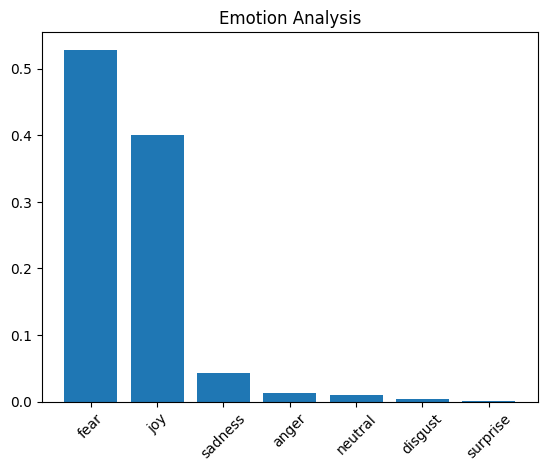

In [17]:
labels = [item['label'] for item in result[0]]
scores = [item['score'] for item in result[0]]

plt.bar(labels, scores)
plt.xticks(rotation=45)
plt.title("Emotion Analysis")
plt.show()

In [18]:
#analisis per baris lirik

lines = lyrics.split("\n")

for line in lines:
    if line.strip() != "":
        print(line)
        print(classifier(line))
        print("------")

Even if I'm on my own
[[{'label': 'fear', 'score': 0.682955801486969}, {'label': 'sadness', 'score': 0.13805034756660461}, {'label': 'joy', 'score': 0.06277427822351456}, {'label': 'neutral', 'score': 0.06045739725232124}, {'label': 'anger', 'score': 0.04253086447715759}, {'label': 'disgust', 'score': 0.007810642011463642}, {'label': 'surprise', 'score': 0.005420600529760122}]]
------
When the silence is deafening
[[{'label': 'fear', 'score': 0.4031960070133209}, {'label': 'disgust', 'score': 0.3086739480495453}, {'label': 'sadness', 'score': 0.1759367734193802}, {'label': 'neutral', 'score': 0.05172749236226082}, {'label': 'anger', 'score': 0.04776133596897125}, {'label': 'surprise', 'score': 0.011290663853287697}, {'label': 'joy', 'score': 0.0014137738617137074}]]
------
I could be stuck here alone
[[{'label': 'sadness', 'score': 0.851016104221344}, {'label': 'neutral', 'score': 0.07188814878463745}, {'label': 'fear', 'score': 0.05601169541478157}, {'label': 'disgust', 'score': 0.008

In [19]:
#visualisasi timeline

emotions_over_time = []

for line in lines:
    if line.strip() != "":
        res = classifier(line)[0]
        top_emotion = max(res, key=lambda x: x['score'])
        emotions_over_time.append(top_emotion['label'])

print(emotions_over_time)

['fear', 'fear', 'sadness', 'fear', 'neutral', 'joy', 'neutral', 'neutral']


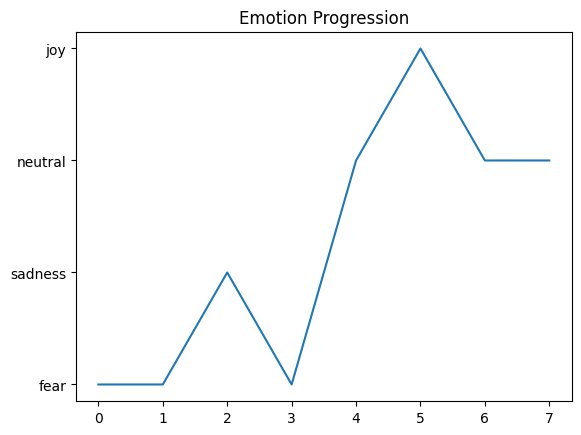

In [20]:
#plot sequence

plt.plot(emotions_over_time)
plt.title("Emotion Progression")
plt.show()

In [21]:
#numerical mapping

emotion_map = {
    'fear': 0,
    'sadness': 1,
    'neutral': 2,
    'joy': 3,
    'anger': 4,
    'disgust': 5,
    'surprise': 6
}

numeric_emotions = [emotion_map[e] for e in emotions_over_time]

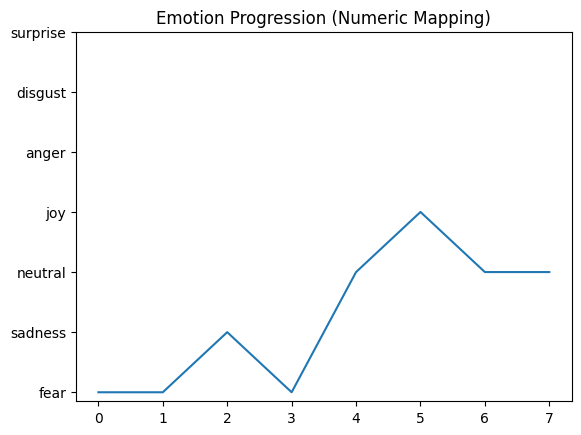

In [22]:
plt.plot(numeric_emotions)
plt.yticks(list(emotion_map.values()), list(emotion_map.keys()))
plt.title("Emotion Progression (Numeric Mapping)")
plt.show()

In [23]:
#label

fear_scores = []
joy_scores = []

for line in lines:
    if line.strip() != "":
        res = classifier(line)[0]
        for item in res:
            if item['label'] == 'fear':
                fear_scores.append(item['score'])
            if item['label'] == 'joy':
                joy_scores.append(item['score'])

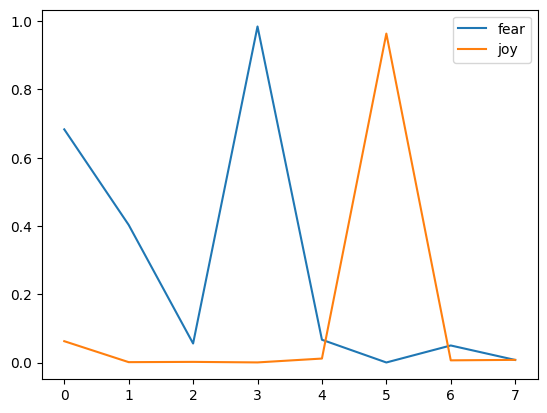

In [24]:
plt.plot(fear_scores, label='fear')
plt.plot(joy_scores, label='joy')
plt.legend()
plt.show()

In [25]:
#dominasi emosi

from collections import Counter

emotion_count = Counter(emotions_over_time)
print(emotion_count)

Counter({'fear': 3, 'neutral': 3, 'sadness': 1, 'joy': 1})


In [26]:
#rata-rata score

import numpy as np

print("Avg Fear:", np.mean(fear_scores))
print("Avg Joy:", np.mean(joy_scores))

Avg Fear: 0.2814843739324715
Avg Joy: 0.13213618384907022
